# Reward Sweep — หา Optimal Reward Config
ทดลอง reward หลาย combination แล้วดู trade-off ระหว่าง FN และ FP

## Cell 1 — Import & Setup (copy จาก turening_refactored)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix, roc_auc_score
from itertools import product

np.random.seed(42)

BASE_FEATURES = ['Progression', 'Migration', 'Aggravation', 'TEMP', 'Rebound', 'WBC', 'Neut']
TARGET        = 'appendicitis'
N_STATES      = 512
N_ACTIONS     = 2
ALPHA         = 0.05
GAMMA         = 0.9
EPSILON       = 0.1
EPOCHS        = 2000

def to_bin(val):
    return 1 if str(val).lower().strip() in {'yes', '1', '1.0', '>10000', '>75', '>37.8', 'app'} else 0

def build_states(df, base_features):
    data = df[base_features].applymap(to_bin).copy()
    data['High_Risk']    = ((data['TEMP'] == 1) & (data['WBC'] == 1) & (data['Rebound'] == 1)).astype(int)
    data['Classic_Sign'] = ((data['Migration'] == 1) & (data['Progression'] == 1)).astype(int)
    all_features = base_features + ['High_Risk', 'Classic_Sign']
    return np.array([int(''.join(map(str, row)), 2) for row in data[all_features].values])

def epsilon_greedy(q_row, eps):
    return np.random.choice(N_ACTIONS) if np.random.rand() < eps else int(np.argmax(q_row))

def train_one_config(reward_cfg, train_states, y_train):
    """Train Q-Learning ด้วย reward config ที่กำหนด คืน q_table"""
    Q = np.zeros((N_STATES, N_ACTIONS))
    for epoch in range(EPOCHS):
        for i in range(len(train_states)):
            s, truth = train_states[i], int(y_train[i])
            a = epsilon_greedy(Q[s], EPSILON)

            if   a == 1 and truth == 1: rew = reward_cfg['TP']
            elif a == 0 and truth == 0: rew = reward_cfg['TN']
            elif a == 1 and truth == 0: rew = reward_cfg['FP']
            else:                       rew = reward_cfg['FN']

            target  = rew + GAMMA * np.max(Q[s])
            Q[s, a] += ALPHA * (target - Q[s, a])
    return Q

def evaluate(Q, states, y_true):
    preds = np.argmax(Q[states], axis=1)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    total       = len(y_true)
    accuracy    = (tp + tn) / total
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Accuracy=accuracy, Sensitivity=sensitivity,
                Specificity=specificity, F1=f1)

print("✅ Setup เสร็จ")

✅ Setup เสร็จ


## Cell 2 — Load Data

In [ ]:
df_train = pd.read_csv('TRAIN_DATASET.csv')
df_test  = pd.read_csv('TEST_DATASET.csv')

train_states = build_states(df_train, BASE_FEATURES)
y_train      = df_train[TARGET].map(to_bin).values
test_states  = build_states(df_test,  BASE_FEATURES)
y_test       = df_test[TARGET].map(to_bin).values

print(f"Train: {len(y_train)} | Test: {len(y_test)}")
print(f"Test  — Positive: {y_test.sum()} | Negative: {(y_test==0).sum()}")

Train: 500 | Test: 500
Test  — Positive: 356 | Negative: 144


/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2696481559.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = df[base_features].applymap(to_bin).copy()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2696481559.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = df[base_features].applymap(to_bin).copy()


## Cell 3 — Reward Sweep

ทดลอง FN penalty และ FP penalty หลายค่า แล้วดูว่า combination ไหนให้ผลดีที่สุด

- **FN_penalties**: ค่าลบที่หักเมื่อพลาดคนป่วย
- **FP_penalties**: ค่าลบที่หักเมื่อผ่าเก้อ
- TP และ TN คงที่ที่ +15 และ +10

In [3]:
# --- กำหนด grid ที่จะ sweep ---
FN_penalties = [-50, -100, -150, -200, -300, -500]   # แกน Y
FP_penalties = [-20, -50,  -80, -100, -150, -200]    # แกน X

sweep_results = []
total_runs = len(FN_penalties) * len(FP_penalties)
run = 0

for fn_pen, fp_pen in product(FN_penalties, FP_penalties):
    run += 1
    cfg = {'TP': 15, 'TN': 10, 'FP': fp_pen, 'FN': fn_pen}
    Q   = train_one_config(cfg, train_states, y_train)
    m   = evaluate(Q, test_states, y_test)
    sweep_results.append({
        'FN_pen': fn_pen, 'FP_pen': fp_pen,
        'Ratio': round(abs(fn_pen / fp_pen), 2),
        **m
    })
    if run % 6 == 0 or run == total_runs:
        print(f"[{run:2d}/{total_runs}] FN={fn_pen:4d}, FP={fp_pen:4d} → "
              f"Sens={m['Sensitivity']:.2%}, Spec={m['Specificity']:.2%}, "
              f"F1={m['F1']:.4f}, FN={m['FN']}, FP={m['FP']}")

df_sweep = pd.DataFrame(sweep_results)
print(f"\n✅ Sweep เสร็จ — {total_runs} combinations")

[ 6/36] FN= -50, FP=-200 → Sens=60.39%, Spec=83.33%, F1=0.7227, FN=141, FP=24
[12/36] FN=-100, FP=-200 → Sens=80.62%, Spec=62.50%, F1=0.8235, FN=69, FP=54
[18/36] FN=-150, FP=-200 → Sens=83.43%, Spec=56.25%, F1=0.8296, FN=59, FP=63
[24/36] FN=-200, FP=-200 → Sens=87.64%, Spec=50.69%, F1=0.8444, FN=44, FP=71
[30/36] FN=-300, FP=-200 → Sens=91.85%, Spec=40.28%, F1=0.8505, FN=29, FP=86
[36/36] FN=-500, FP=-200 → Sens=92.98%, Spec=36.81%, F1=0.8509, FN=25, FP=91

✅ Sweep เสร็จ — 36 combinations


## Cell 4 — ตารางผลเรียงตาม F1

In [4]:
# เรียงตาม F1 ก่อน แล้ว Sensitivity
df_ranked = (
    df_sweep
    .sort_values(['F1', 'Sensitivity'], ascending=[False, False])
    .reset_index(drop=True)
)

display_cols = ['FN_pen', 'FP_pen', 'Ratio', 'Accuracy', 'Sensitivity',
                'Specificity', 'F1', 'TP', 'TN', 'FP', 'FN']

df_show = df_ranked[display_cols].copy()
for col in ['Accuracy', 'Sensitivity', 'Specificity']:
    df_show[col] = df_show[col].map(lambda x: f"{x:.2%}")
df_show['F1'] = df_show['F1'].map(lambda x: f"{x:.4f}")

print("Top 10 Reward Configs (เรียงตาม F1):")
print("="*90)
print(df_show.head(10).to_string(index=True))
print("="*90)

# หา sweet spot: Sensitivity >= 90% และ Specificity สูงสุด
candidates = df_ranked[(df_ranked['Sensitivity'] >= 0.90)].copy()
best = candidates.sort_values(['Specificity', 'F1'], ascending=[False, False]).iloc[0]
print(f"\n🎯 Sweet Spot แนะนำ:")
print(f"   FN penalty = {best['FN_pen']} | FP penalty = {best['FP_pen']} | Ratio = {best['Ratio']}")
print(f"   Sensitivity = {best['Sensitivity']:.2%} | Specificity = {best['Specificity']:.2%} | F1 = {best['F1']:.4f}")
print(f"   FN = {best['FN']} | FP = {best['FP']}")

Top 10 Reward Configs (เรียงตาม F1):
   FN_pen  FP_pen  Ratio Accuracy Sensitivity Specificity      F1   TP  TN  FP  FN
0    -100    -100   1.00   78.20%      89.89%      49.31%  0.8545  320  71  73  36
1     -50     -20   2.50   76.80%      92.98%      36.81%  0.8509  331  53  91  25
2    -100     -50   2.00   76.80%      92.98%      36.81%  0.8509  331  53  91  25
3    -150     -80   1.88   76.80%      92.98%      36.81%  0.8509  331  53  91  25
4    -200     -80   2.50   76.80%      92.98%      36.81%  0.8509  331  53  91  25
5    -200    -100   2.00   76.80%      92.98%      36.81%  0.8509  331  53  91  25
6    -300    -150   2.00   76.80%      92.98%      36.81%  0.8509  331  53  91  25
7    -500    -200   2.50   76.80%      92.98%      36.81%  0.8509  331  53  91  25
8    -100     -80   1.25   77.00%      91.85%      40.28%  0.8505  327  58  86  29
9    -150    -100   1.50   77.00%      91.85%      40.28%  0.8505  327  58  86  29

🎯 Sweet Spot แนะนำ:
   FN penalty = -100.0 | FP p

## Cell 5 — Visualization

/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/3482142798.py:37: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/3482142798.py:37: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/3482142798.py:37: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/3482142798.py:37: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/3482142798.py:37: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121

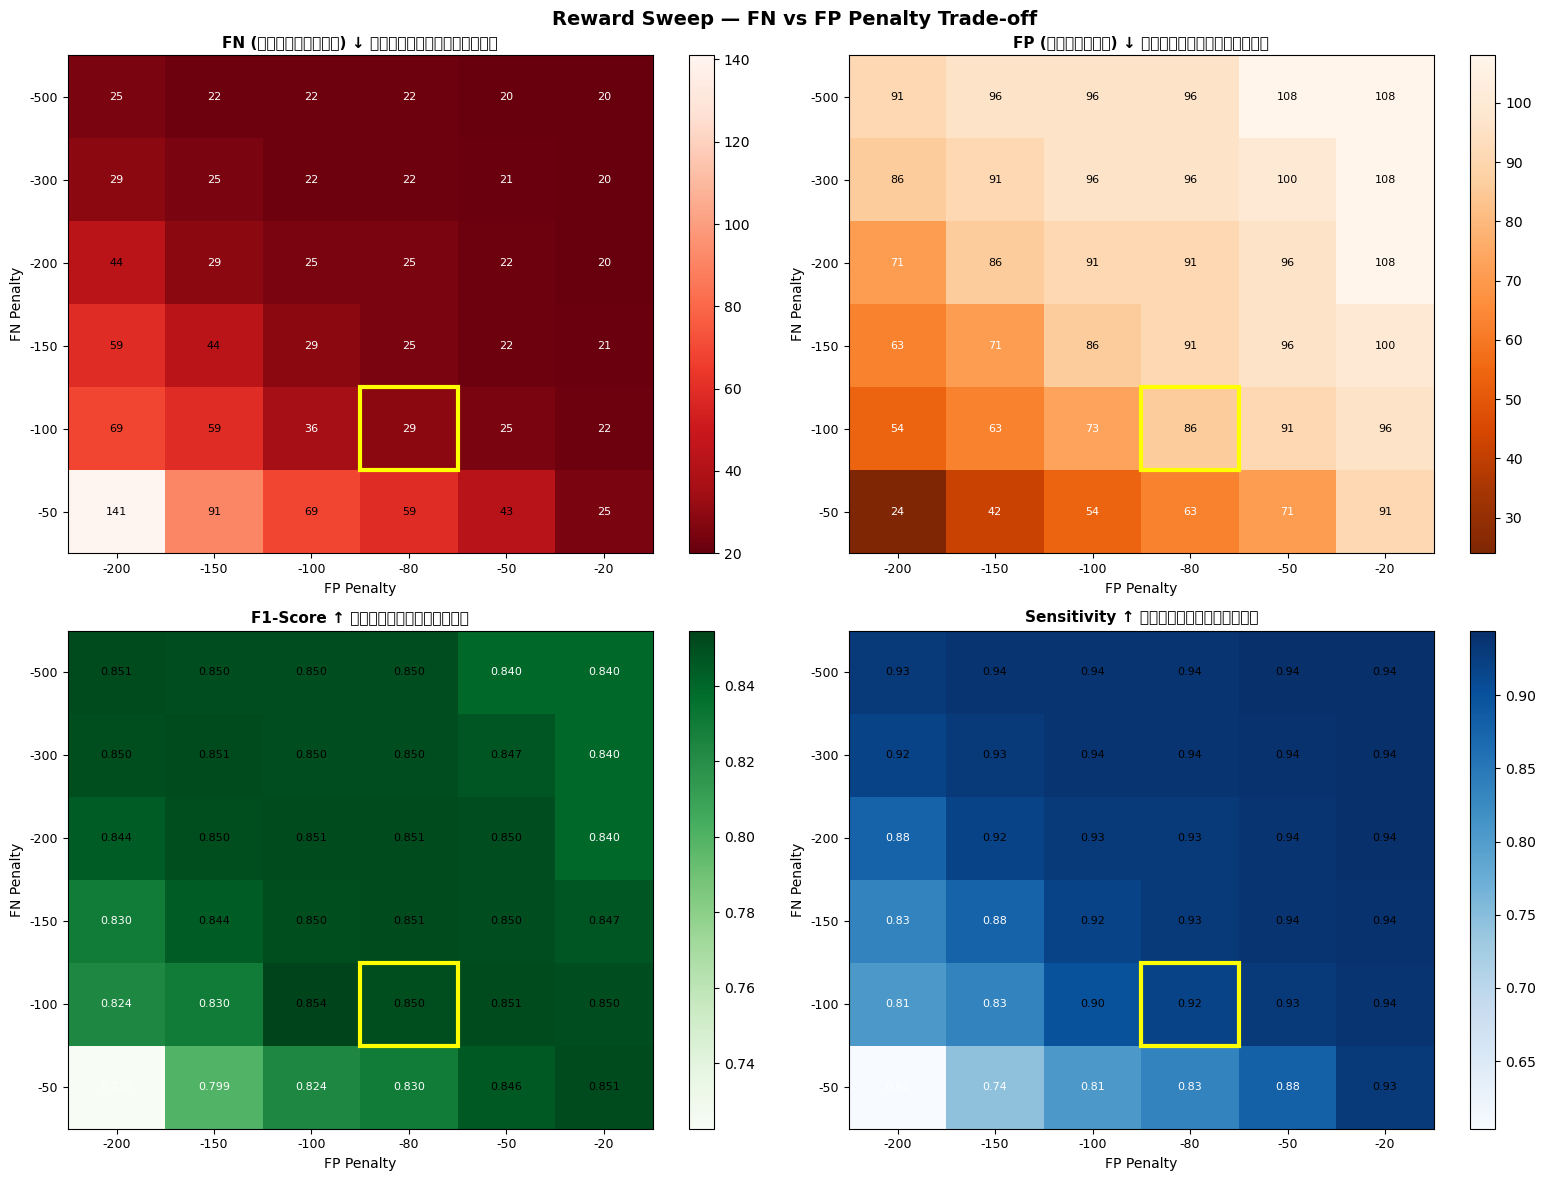

💾 บันทึกกราฟเป็น reward_sweep_heatmap.png แล้ว
🟡 กรอบเหลือง = Sweet Spot (FN=-100.0, FP=-80.0)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Reward Sweep — FN vs FP Penalty Trade-off', fontsize=14, fontweight='bold')

pivot_fn   = df_sweep.pivot(index='FN_pen', columns='FP_pen', values='FN')
pivot_fp   = df_sweep.pivot(index='FN_pen', columns='FP_pen', values='FP')
pivot_f1   = df_sweep.pivot(index='FN_pen', columns='FP_pen', values='F1')
pivot_sens = df_sweep.pivot(index='FN_pen', columns='FP_pen', values='Sensitivity')

def heatmap(ax, data, title, fmt, cmap):
    im = ax.imshow(data.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_xlabel('FP Penalty', fontsize=10)
    ax.set_ylabel('FN Penalty', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.values[i, j]
            ax.text(j, i, fmt.format(val), ha='center', va='center',
                    fontsize=8, color='white' if val < data.values.mean() else 'black')

heatmap(axes[0,0], pivot_fn,   'FN (คนไข้หลุด) ↓ ยิ่งน้อยยิ่งดี',   '{:.0f}',  'Reds_r')
heatmap(axes[0,1], pivot_fp,   'FP (ผ่าเก้อ) ↓ ยิ่งน้อยยิ่งดี',     '{:.0f}',  'Oranges_r')
heatmap(axes[1,0], pivot_f1,   'F1-Score ↑ ยิ่งสูงยิ่งดี',           '{:.3f}',  'Greens')
heatmap(axes[1,1], pivot_sens, 'Sensitivity ↑ ยิ่งสูงยิ่งดี',        '{:.2f}',  'Blues')

# Mark sweet spot
fn_idx = list(pivot_f1.index).index(best['FN_pen'])
fp_idx = list(pivot_f1.columns).index(best['FP_pen'])
for ax in axes.flat:
    ax.add_patch(plt.Rectangle((fp_idx-0.5, fn_idx-0.5), 1, 1,
                                fill=False, edgecolor='yellow', linewidth=3))

plt.tight_layout()
plt.savefig('reward_sweep_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 บันทึกกราฟเป็น reward_sweep_heatmap.png แล้ว")
print(f"🟡 กรอบเหลือง = Sweet Spot (FN={best['FN_pen']}, FP={best['FP_pen']})")

## Cell 6 — Scatter: FN vs FP ทุก config

/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2670602173.py:27: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2670602173.py:27: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2670602173.py:27: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2670602173.py:27: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_96506/2670602173.py:27: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000

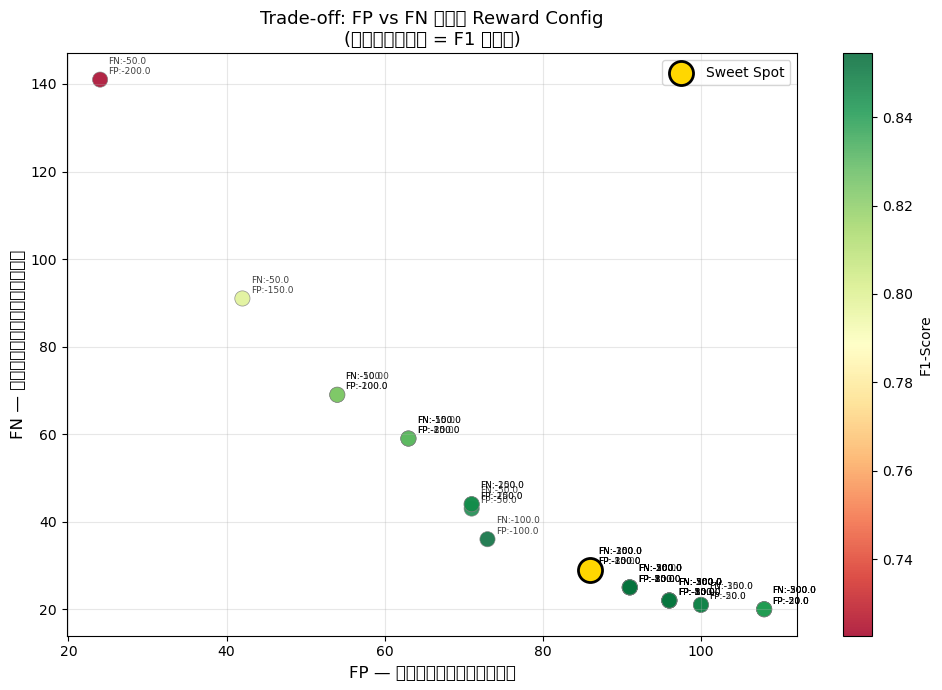

💾 บันทึกกราฟเป็น reward_sweep_scatter.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    df_sweep['FP'], df_sweep['FN'],
    c=df_sweep['F1'], cmap='RdYlGn',
    s=120, alpha=0.85, edgecolors='gray', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='F1-Score')

# Label แต่ละจุด
for _, row in df_sweep.iterrows():
    ax.annotate(f"FN:{row['FN_pen']}\nFP:{row['FP_pen']}",
                (row['FP'], row['FN']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=6.5, alpha=0.75)

# Mark sweet spot
ax.scatter(best['FP'], best['FN'], s=300, color='gold',
           edgecolors='black', linewidth=2, zorder=5, label='Sweet Spot')

ax.set_xlabel('FP — จำนวนผ่าเก้อ', fontsize=12)
ax.set_ylabel('FN — จำนวนคนไข้หลุด', fontsize=12)
ax.set_title('Trade-off: FP vs FN ทุก Reward Config\n(สีเขียว = F1 สูง)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reward_sweep_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 บันทึกกราฟเป็น reward_sweep_scatter.png")